# Notebook 5 — Connections: containment, information, identity
## Three short demos, each on a constantly-confused distinction

Mary's clinical data has been growing through four notebooks: she has a timeline (NB1), participating people and a biopsy (NB2), an anatomically structured breast (NB3), and qualitative and quantitative features attached to her specimen (NB4). Three kinds of *connection* remain undertreated — connections that learners routinely conflate but that SULO keeps strictly distinct.

1. **Spatial containment is not parthood.** Mary's tumour is *located in* her breast (`isIn`) but is not *a part of* the breast (`isPartOf`/`hasPart`). The two relations have different transitivity behaviour and different inferences. (§1)
2. **Information is not what it is about.** A *diagnosis statement* is an `InformationObject` that `refersTo` a disease — but it is not the disease. Quality features carried by the statement (preliminary, confirmed) are features of the *record*, not of the disease. (§2)
3. **Identity across systems is a separate axiom.** Mary's individual in our ontology and her record in another system (e.g. FHIR) are distinct URIs; only `owl:sameAs` declares them coreferential. Within our ontology, `AllDifferent` lets us count distinct sub-process individuals correctly. (§3)

## Learning objectives

1. Distinguish `sulo:isIn` (spatial containment, transitive) from `sulo:isPartOf` (mereological composition, transitive but disjoint with containment); demonstrate the distinction with Mary's tumour
2. Build the diagnosis triangle — `DiagnosticAssessment` (Process) outputs `DiagnosisStatement` (InformationObject) that `refersTo` `BreastCancer` (Process) — and use a **value restriction** (`hasFeature.value(confirmed_status)`) to classify Mary's confirmed diagnosis
3. Model the prescription→administration relation using `refersTo` directly on `MedicationPrescription`, linking it to its `MedicationAdministration` individuals
4. Use `AllDifferent` to assert pairwise distinctness over the chemotherapy administration individuals, and `owl:sameAs` to link Mary's MIE individual to a mock FHIR `Patient/12345`
5. Query the assembled ontology with SPARQL to demonstrate that these connection patterns retrieve what we want — distinct counts, prescription→administration traversal, cross-system identity

## What we will *not* do

- **No new properties.** Containment, information reference, and identity are all expressed with SULO's existing properties (`isIn`, `hasPart`, `hasFeature`, `refersTo`) and standard OWL constructs (`AllDifferent`, `owl:sameAs`).
- **No state-change semantics over time.** Mary's diagnosis evolves from preliminary to confirmed by the addition of a quality feature — we do not model the *transition* with temporal logic, only the two states as distinct statements.


## Setting up

We reload SULO, PRO, and the MIE checkpoint produced by NB4.

In [1]:
import sys, os, datetime
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append("dist")

sulo = get_ontology("dist/sulo.owl").load()
pro  = get_ontology("dist/pro.owl").load()
mie  = get_ontology("dist/mie-04.owl").load()

print(f"MIE classes:                 {len(list(mie.classes()))}")
print(f"MIE individuals:             {len(list(mie.individuals()))}")
print(f"MIE object properties (local): {len(list(mie.object_properties()))}  ← still zero")

MIE classes:                 42
MIE individuals:             54
MIE object properties (local): 0  ← still zero


## §1 — `isIn` is not `isPartOf`

Mary's tumour grows *within* her left breast. Three temptations follow:

1. *"The tumour is part of the breast."* — Wrong. Parts compose the breast's normal anatomy (NB3): nipple, gland, adipose, skin. The tumour is pathological tissue at the same spatial location; it is *not* a structural component. Modelling it as `hasPart` would mean every grade-2 tumour in a breast turns that breast into something with grade-2 parts — clinically nonsensical.
2. *"The tumour is located in the breast, so make it a part anyway."* — Same mistake, no better dressing.
3. *"There's no difference between containment and parthood, just use one of them everywhere."* — The OWL reasoner uses them differently. `isPartOf` interacts with the closure axioms we placed on `Breast` in NB3; `isIn` does not. Conflating them either lets pathological tissue *break* the Breast definition, or forces us to drop the closure that made the definition work.

SULO ships both, kept strictly distinct: `sulo:hasPart` / `sulo:isPartOf` for mereological composition, and `sulo:isIn` / `sulo:contains` for spatial containment. Both are transitive; neither is a sub-property of the other.

We declare `Tumour` as a `sulo:SpatialObject`, place Mary's tumour `isIn` her left breast, and define `LocalisedBreastTumour` — any tumour located inside a breast — using an `equivalent_to` over `isIn`.

In [2]:
# Tumour classes and Mary's tumour individual — spatially in the breast, not a part of it
with mie:
    class Tumour(sulo.SpatialObject):
        """An abnormal mass of tissue resulting from neoplastic cell proliferation; not a structural part of normal anatomy."""
        label = [locstr("tumour", "en")]

    class LocalisedBreastTumour(Tumour):
        """A tumour spatially located inside a breast."""
        label = [locstr("localised breast tumour", "en")]
        equivalent_to = [Tumour & sulo.isIn.some(mie.Breast)]

    mary_tumour = Tumour("mary_tumour_left_breast")
    mary_tumour.isIn = [mie.mary_left_breast]


In [3]:
# Reasoner — classify mary_tumour, then check that isIn ≠ hasDirectPart
result = safe_call_reasoner(mie)
print(f"Reasoner ok:          {result['ok']}")
print(f"Inconsistent classes: {result['inconsistent']}")

print("\nInstances of LocalisedBreastTumour:")
for ind in LocalisedBreastTumour.instances():
    print(f"  - {ind.name}")

print("\nMary's left breast — direct parts (anatomy from NB3):")
for p in mie.mary_left_breast.hasDirectPart:
    print(f"  - {p.name}")

print("\nIs mary_tumour a direct part of the breast?")
print(f"  {mary_tumour in mie.mary_left_breast.hasDirectPart}  ← correctly False")
print("\nIs mary_tumour spatially in the breast?")
print(f"  {mie.mary_left_breast in mary_tumour.isIn}  ← correctly True")


Reasoner ok:          True
Inconsistent classes: []

Instances of LocalisedBreastTumour:
  - mary_tumour_left_breast

Mary's left breast — direct parts (anatomy from NB3):
  - mary_left_adipose
  - mary_left_skin
  - mary_left_nipple
  - mary_left_mammary_gland

Is mary_tumour a direct part of the breast?
  False  ← correctly False

Is mary_tumour spatially in the breast?
  True  ← correctly True


## §2 — The diagnosis triangle: `InformationObject refersTo Process`

Three entities take part in a diagnosis, and conflating them is the most common modelling error in clinical informatics:

1. The **disease itself** — the ongoing biological process of malignant cell proliferation. *This is a `sulo:Process`*, not a SpatialObject. The lump and the tumour *are* SpatialObjects (NB3, NB5 §1) — but the *disease* is the ongoing process the body undergoes, and that distinction is what the diagnosis triangle hinges on.
2. The **diagnostic assessment** — the clinician's reasoning event that produces the diagnostic conclusion. *This is also a `sulo:Process`*, already in our ontology since NB1 (`mary_diag_mar01_confirmed`).
3. The **diagnosis statement** — the documentary record stating the conclusion. *This is a `sulo:InformationObject`*. It `refersTo` the disease (the conclusion is about it) and is the *output* of the diagnostic assessment (already attached as an `EmergingRole` participant of the assessment in spirit, though for brevity we will not re-derive the PRO pattern here).

Mary has *two* diagnosis statements in her odyssey — a **preliminary** one written by Dr Smith on Feb 22 and a **confirmed** one written on Mar 1 after the histopathology results. The difference between them is a single quality attached via `hasFeature`. We use a **value restriction** — `hasFeature value confirmed_status` — to define the class `ConfirmedDiagnosis`. The reasoner then classifies the Mar 1 statement but not the Feb 22 one.

In [4]:
# Disease (Process) + statement (InformationObject) — the two outer corners of the triangle
with mie:
    class BreastCancer(sulo.Process):
        """The ongoing pathological process of malignant cell proliferation originating in breast tissue."""
        label = [locstr("breast cancer", "en")]

    class InvasiveCarcinomaOfBreast(BreastCancer):
        """A breast cancer process in which malignant cells have invaded surrounding stroma."""
        label = [locstr("invasive carcinoma of breast", "en")]

    class DiagnosisStatement(sulo.InformationObject):
        """An information object asserting a diagnostic conclusion about a clinical condition."""
        label = [locstr("diagnosis statement", "en")]
        is_a = [sulo.refersTo.some(BreastCancer)]


In [5]:
# Diagnosis status — qualities that decorate a statement; shared status individuals
with mie:
    class DiagnosisStatus(sulo.Quality):
        label = [locstr("diagnosis status", "en")]
    class Preliminary(DiagnosisStatus):
        label = [locstr("preliminary", "en")]
    class Confirmed(DiagnosisStatus):
        label = [locstr("confirmed", "en")]
    AllDisjoint([Preliminary, Confirmed])

    preliminary_status = Preliminary("preliminary_status")
    confirmed_status   = Confirmed("confirmed_status")


In [6]:
# Defined class using `hasFeature value <individual>` + Mary's disease and two statements
with mie:
    class ConfirmedDiagnosis(DiagnosisStatement):
        """A diagnosis statement bearing the canonical confirmed-status quality."""
        label = [locstr("confirmed diagnosis", "en")]
        equivalent_to = [
            DiagnosisStatement & sulo.hasFeature.value(confirmed_status)
        ]

    mary_breast_cancer = InvasiveCarcinomaOfBreast("mary_breast_cancer")

    mary_dx_feb22 = DiagnosisStatement("mary_dx_statement_feb22")
    mary_dx_feb22.refersTo  = [mary_breast_cancer]
    mary_dx_feb22.hasFeature = [preliminary_status]

    mary_dx_mar01 = DiagnosisStatement("mary_dx_statement_mar01")
    mary_dx_mar01.refersTo  = [mary_breast_cancer]
    mary_dx_mar01.hasFeature = [confirmed_status]


In [7]:
# Reasoner — only the March 1 statement should classify as ConfirmedDiagnosis
result = safe_call_reasoner(mie)
print(f"Reasoner ok:          {result['ok']}")
print(f"Inconsistent classes: {result['inconsistent']}")

print("\nInstances of ConfirmedDiagnosis after reasoning:")
for ind in ConfirmedDiagnosis.instances():
    print(f"  - {ind.name}")

for s in [mary_dx_feb22, mary_dx_mar01]:
    confirmed = s in ConfirmedDiagnosis.instances()
    features = [f.name for f in s.hasFeature]
    print(f"\n  {s.name}")
    print(f"    refersTo:    {[r.name for r in s.refersTo]}")
    print(f"    hasFeature:  {features}")
    print(f"    confirmed?   {'✓' if confirmed else '✗'}")


Reasoner ok:          True
Inconsistent classes: []

Instances of ConfirmedDiagnosis after reasoning:
  - mary_dx_statement_mar01

  mary_dx_statement_feb22
    refersTo:    ['mary_breast_cancer']
    hasFeature:  ['preliminary_status']
    confirmed?   ✗

  mary_dx_statement_mar01
    refersTo:    ['mary_breast_cancer']
    hasFeature:  ['confirmed_status']
    confirmed?   ✓


## §3 — Prescriptions and identity

On Mar 10 Mary begins neoadjuvant chemotherapy. A **prescription** has been written before that date — a clinical plan stating *which* infusions Mary is expected to receive. The prescription is a `MedicationPrescription` (an `InformationObject`) that `refersTo` the `MedicationAdministration` individuals directly (Manchester syntax):

```
Class: MedicationPrescription
  SubClassOf:
    refersTo some MedicationAdministration
```

Four administration sub-processes are created (a simplification of the AC-T regimen — 4 cycles in total), each a `hasPart` of `mary_chemo_2026` (the chemotherapy process from NB1). Mary's prescription `refersTo` each of them directly.

We then make the **identity** moves:

- **`AllDifferent`** over the four administration individuals — without this, OWL's open world allows `sameAs` between any two cycles, and `COUNT(DISTINCT ?cycle)` may return a smaller number than expected.
- **`owl:sameAs`** linking Mary's MIE individual to a mock external `Patient/12345`. Two URIs, one person. Any system that consumes both ontologies and chases `sameAs` can merge their views of the patient.


In [8]:
# Process + InformationObject classes for the chemo prescription pattern
with mie:
    class MedicationAdministration(sulo.Process):
        """A process in which a clinical drug is administered to a subject of care."""
        label = [locstr("medication administration", "en")]

    class MedicationPrescription(sulo.InformationObject):
        """A clinical plan for administering medication."""
        label = [locstr("medication prescription", "en")]
        is_a = [sulo.refersTo.only(MedicationAdministration)]


In [9]:
# Mary's four administrations as sub-processes; prescription refersTo them directly
with mie:
    mary_chemo_admins = []
    for i in range(1, 5):
        a = MedicationAdministration(f"mary_chemo_admin_{i}")
        mary_chemo_admins.append(a)
    mie.mary_chemo_2026.hasPart = list(mary_chemo_admins)

    mary_chemo_prescription = MedicationPrescription("mary_chemo_prescription")
    mary_chemo_prescription.refersTo = list(mary_chemo_admins)


In [10]:
# AllDifferent on the four cycles + owl:sameAs bridging MIE.mary to FHIR.Patient/12345
with mie:
    AllDifferent(list(mary_chemo_admins))

    fhir_patient_12345 = mie.Person("fhir_patient_12345")
    fhir_patient_12345.label = [locstr("FHIR Patient/12345", "en")]
    mie.mary.equivalent_to.append(fhir_patient_12345)

result = safe_call_reasoner(mie)
print(f"Reasoner ok:          {result['ok']}")
print(f"Inconsistent classes: {result['inconsistent']}")


Reasoner ok:          True
Inconsistent classes: []


### Verifying with SPARQL

Three queries make the three connection patterns visible.

**Query 1 — counting distinct administrations.** Because we asserted `AllDifferent`, `COUNT(DISTINCT ?a)` over the prescription's `refersTo` links returns the true count of four.

**Query 2 — traversing prescription → administration.** A single hop through `refersTo` recovers the administrations referred to by Mary's prescription.

**Query 3 — recognising sameAs.** `mary` and `fhir_patient_12345` are distinct URIs in the graph; an OWL-aware consumer follows the `sameAs` assertion to merge their views.


In [11]:
# Query 1 — count distinct administrations referred to by Mary's prescription
rows = list(default_world.sparql("""
    PREFIX sulo: <https://w3id.org/sulo/>
    PREFIX mie: <https://w3id.org/ontostart/mie/>
    SELECT (COUNT(DISTINCT ?a) AS ?n) WHERE {
        mie:mary_chemo_prescription sulo:refersTo ?a
    }
"""))
print(f"Q1 — distinct administrations referred to by Mary's prescription: {rows[0][0]}")


Q1 — distinct administrations referred to by Mary's prescription: 4


In [12]:
# Query 2 — prescription → administration (direct)
rows = list(default_world.sparql("""
    PREFIX sulo: <https://w3id.org/sulo/>
    PREFIX mie: <https://w3id.org/ontostart/mie/>
    SELECT ?admin WHERE {
        mie:mary_chemo_prescription sulo:refersTo ?admin
    } ORDER BY ?admin
"""))
print("Q2 — administrations referred to by Mary's prescription:")
for r in rows:
    print(f"  - {r[0].name}")


Q2 — administrations referred to by Mary's prescription:
  - mary_chemo_admin_1
  - mary_chemo_admin_2
  - mary_chemo_admin_3
  - mary_chemo_admin_4


In [13]:
# Query 3 — owl:sameAs asserted on Mary (the FHIR bridge)
rows = list(default_world.sparql("""
    PREFIX owl: <http://www.w3.org/2002/07/owl#>
    PREFIX mie: <https://w3id.org/ontostart/mie/>
    SELECT ?other WHERE { mie:mary owl:sameAs ?other }
"""))
print("Q3 — entities asserted owl:sameAs as Mary:")
for r in rows:
    print(f"  - {r[0].name}  ({r[0].iri})")


Q3 — entities asserted owl:sameAs as Mary:
  - fhir_patient_12345  (https://w3id.org/ontostart/mie/fhir_patient_12345)


## §4 — Recap: three SULO connection patterns, three lessons

| Connection | Right SULO move | Wrong move that conflates |
|---|---|---|
| Spatial containment | `sulo:isIn` (transitive) — distinct from `sulo:hasPart` / `sulo:isPartOf` | Modelling a tumour as `hasPart` of the breast |
| Information about a referent | `InformationObject refersTo Process/Object` + qualities on the *statement* | Putting confirmation status on the disease itself, or modelling the disease as a SpatialObject |
| Prescription → administration | `MedicationPrescription refersTo MedicationAdministration` (direct) | Defining an empty placeholder individual for administration before it exists at prescription time |
| Identity within an ontology | `AllDifferent` (so the reasoner does not unify) | Trusting *URI* distinctness alone — under OWA, two URIs can be `sameAs` unless told otherwise |
| Identity across systems | `owl:sameAs` | Inventing a `mappedTo` or `sourceSystemId` property |

The three short demos above each chose the SULO move and bypassed the conflation. None of them required a new property on the MIE ontology — the property count remains zero.


## §5 — Save the checkpoint

We save the ontology as `dist/mie-05.owl`. NB6 will exercise the full assembled ontology with a small set of SPARQL queries that reconstruct Mary's clinical record. NB7 will FAIR-publish the result.

Saved dist/mie-05.owl
  classes:                   53
  individuals:               66
  object properties (local): 0  ← still zero
  data properties (local):   0    ← still zero
  imported ontologies:       ['https://w3id.org/sulo/', 'https://w3id.org/ontostart/pro/']


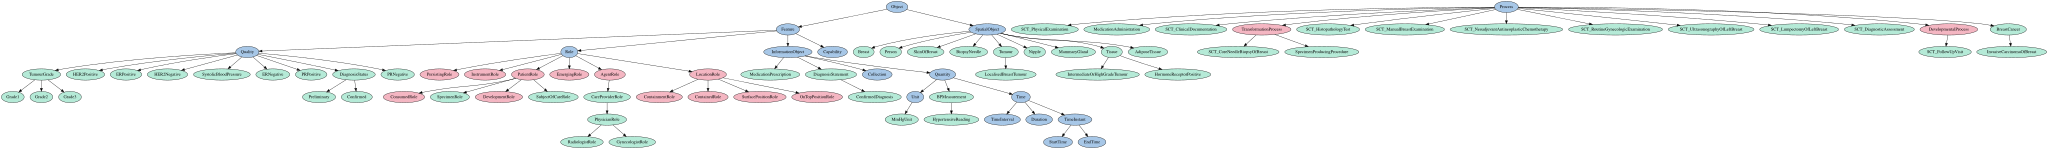

In [14]:
os.makedirs("dist", exist_ok=True)
mie.save(file="dist/mie-05.owl", format="rdfxml")
print("Saved dist/mie-05.owl")
print(f"  classes:                   {len(list(mie.classes()))}")
print(f"  individuals:               {len(list(mie.individuals()))}")
print(f"  object properties (local): {len(list(mie.object_properties()))}  ← still zero")
print(f"  data properties (local):   {len(list(mie.data_properties()))}    ← still zero")
print(f"  imported ontologies:       {[o.base_iri for o in mie.imported_ontologies]}")

tree = get_color_tree([sulo, pro, mie])
display(tree)